In [1]:
from pathlib import Path
import sys
import torch
import numpy as np

PROJECT_ROOT = Path.cwd().parent

V3_DIR = (
    PROJECT_ROOT
    / "src"
    / "v3_2.5d_unet_model"
)

CHECKPOINT = (
    PROJECT_ROOT
    / "models"
    / "v3"
    / "best.pt"
)

VAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "v3"
    / "val"
)

print("Project root:", PROJECT_ROOT)
print("Validation directory:", VAL_DIR)
print("Checkpoint:", CHECKPOINT)

print(
    "Validation directory exists:",
    VAL_DIR.exists()
)

print(
    "Checkpoint exists:",
    CHECKPOINT.exists()
)

Project root: /Users/abhra/Downloads/AI-ML/Resume/BraTS
Validation directory: /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/processed/v3/val
Checkpoint: /Users/abhra/Downloads/AI-ML/Resume/BraTS/models/v3/best.pt
Validation directory exists: True
Checkpoint exists: True


In [5]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [2]:
import importlib.util

V3_DATASET_PATH = (
    V3_DIR
    / "dataset.py"
)

spec = importlib.util.spec_from_file_location(
    "v3_dataset_eval",
    V3_DATASET_PATH
)

v3_dataset_module = (
    importlib.util.module_from_spec(spec)
)

spec.loader.exec_module(
    v3_dataset_module
)

BraTS25DDataset = (
    v3_dataset_module.BraTS25DDataset
)

val_dataset = BraTS25DDataset(
    VAL_DIR
)

print(
    "Validation samples:",
    len(val_dataset)
)

Loaded 252 patients with 4000 samples
Validation samples: 4000


In [3]:
from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print(
    "Validation batches:",
    len(val_loader)
)

Validation batches: 500


In [6]:
V3_MODEL_PATH = (
    V3_DIR
    / "unet_v3.py"
)

spec = importlib.util.spec_from_file_location(
    "unet_v3_eval",
    V3_MODEL_PATH
)

v3_model_module = (
    importlib.util.module_from_spec(spec)
)

spec.loader.exec_module(
    v3_model_module
)

UNetV3 = (
    v3_model_module.UNetV3
)

model = UNetV3(
    in_channels=12,
    out_channels=1
).to(device)

In [7]:
checkpoint = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Validation Dice during training:",
    checkpoint["val_dice"]
)

print(
    "Validation IoU during training:",
    checkpoint["val_iou"]
)

print(
    "Model device:",
    next(model.parameters()).device
)

Checkpoint epoch: 9
Validation Dice during training: 0.839937910914421
Validation IoU during training: 0.8078601492643356
Model device: mps:0


In [8]:
# ==================================================
# V3 Forward Pass
# ==================================================

images, masks = next(
    iter(val_loader)
)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():

    logits = model(images)

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities > 0.5
    ).float()

print()
print("Logits shape:", logits.shape)
print(
    "Probabilities shape:",
    probabilities.shape
)

print(
    "Predictions shape:",
    predictions.shape
)

print()
print(
    "Probability range:",
    probabilities.min().item(),
    "→",
    probabilities.max().item()
)

print(
    "Prediction values:",
    torch.unique(predictions)
)

Images shape: torch.Size([8, 12, 128, 128])
Masks shape: torch.Size([8, 128, 128])

Logits shape: torch.Size([8, 1, 128, 128])
Probabilities shape: torch.Size([8, 1, 128, 128])
Predictions shape: torch.Size([8, 1, 128, 128])

Probability range: 2.4961994693484257e-09 → 0.9999996423721313
Prediction values: tensor([0., 1.], device='mps:0')


In [9]:
# ==================================================
# V3 FULL VALIDATION
# ==================================================

import numpy as np
import torch

model.eval()

THRESHOLD = 0.5
SMOOTH = 1e-6

total_intersection = 0.0
total_pred = 0.0
total_target = 0.0

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

slice_dice_scores = []
slice_iou_scores = []

tumor_slice_dice = []
empty_slice_dice = []

tumor_slice_count = 0
empty_slice_count = 0


with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        masks = masks.to(device)

        logits = model(images)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities > THRESHOLD
        ).float()

        targets = masks.unsqueeze(1)

        # ------------------------------------------
        # Flatten each slice
        # ------------------------------------------

        predictions_flat = predictions.flatten(1)
        targets_flat = targets.flatten(1)

        # ------------------------------------------
        # Per-slice metrics
        # ------------------------------------------

        intersection = (
            predictions_flat
            * targets_flat
        ).sum(dim=1)

        pred_sum = (
            predictions_flat.sum(dim=1)
        )

        target_sum = (
            targets_flat.sum(dim=1)
        )

        dice = (
            2 * intersection + SMOOTH
        ) / (
            pred_sum
            + target_sum
            + SMOOTH
        )

        union = (
            pred_sum
            + target_sum
            - intersection
        )

        iou = (
            intersection + SMOOTH
        ) / (
            union + SMOOTH
        )

        slice_dice_scores.extend(
            dice.cpu().numpy()
        )

        slice_iou_scores.extend(
            iou.cpu().numpy()
        )

        # ------------------------------------------
        # Tumor / empty slices
        # ------------------------------------------

        for i in range(
            len(target_sum)
        ):

            if target_sum[i].item() > 0:

                tumor_slice_count += 1

                tumor_slice_dice.append(
                    dice[i].item()
                )

            else:

                empty_slice_count += 1

                empty_slice_dice.append(
                    dice[i].item()
                )

        # ------------------------------------------
        # Global pixel counts
        # ------------------------------------------

        total_intersection += (
            intersection.sum().item()
        )

        total_pred += (
            pred_sum.sum().item()
        )

        total_target += (
            target_sum.sum().item()
        )

        # ------------------------------------------
        # Confusion matrix
        # ------------------------------------------

        pred_bool = (
            predictions > 0.5
        )

        target_bool = (
            targets > 0.5
        )

        total_tp += (
            (pred_bool & target_bool)
            .sum()
            .item()
        )

        total_fp += (
            (pred_bool & ~target_bool)
            .sum()
            .item()
        )

        total_fn += (
            (~pred_bool & target_bool)
            .sum()
            .item()
        )

        total_tn += (
            (~pred_bool & ~target_bool)
            .sum()
            .item()
        )


# ==================================================
# Final metrics
# ==================================================

overall_pixel_dice = (
    2 * total_intersection + SMOOTH
) / (
    total_pred
    + total_target
    + SMOOTH
)

overall_iou = (
    total_intersection + SMOOTH
) / (
    total_pred
    + total_target
    - total_intersection
    + SMOOTH
)

mean_slice_dice = np.mean(
    slice_dice_scores
)

mean_slice_iou = np.mean(
    slice_iou_scores
)

tumor_dice = np.mean(
    tumor_slice_dice
)

empty_dice = np.mean(
    empty_slice_dice
)

precision = (
    total_tp
    / (
        total_tp
        + total_fp
        + SMOOTH
    )
)

recall = (
    total_tp
    / (
        total_tp
        + total_fn
        + SMOOTH
    )
)

specificity = (
    total_tn
    / (
        total_tn
        + total_fp
        + SMOOTH
    )
)


# ==================================================
# Print results
# ==================================================

print("=" * 60)
print("V3 FULL VALIDATION RESULTS")
print("=" * 60)

print(
    f"Overall Pixel Dice:   {overall_pixel_dice:.4f}"
)

print(
    f"Mean Slice Dice:      {mean_slice_dice:.4f}"
)

print(
    f"Tumor Slice Dice:     {tumor_dice:.4f}"
)

print(
    f"IoU:                  {overall_iou:.4f}"
)

print(
    f"Precision:            {precision:.4f}"
)

print(
    f"Recall:               {recall:.4f}"
)

print(
    f"Specificity:          {specificity:.4f}"
)

print()

print(
    "Tumor slices:",
    tumor_slice_count
)

print(
    "Empty slices:",
    empty_slice_count
)

print()

print("Confusion Matrix")
print("-" * 30)

print(
    "TP:",
    total_tp
)

print(
    "FP:",
    total_fp
)

print(
    "FN:",
    total_fn
)

print(
    "TN:",
    total_tn
)

V3 FULL VALIDATION RESULTS
Overall Pixel Dice:   0.9277
Mean Slice Dice:      0.8399
Tumor Slice Dice:     0.8508
IoU:                  0.8652
Precision:            0.9177
Recall:               0.9380
Specificity:          0.9989

Tumor slices: 1992
Empty slices: 2008

Confusion Matrix
------------------------------
TP: 763291
FP: 68493
FN: 50431
TN: 64653785


In [11]:
# ==================================================
# V3 Tumor Slice Analysis
# ==================================================

tumor_slice_results = []

sample_index = 0

model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        logits = model(images)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities > 0.5
        ).float()

        targets = masks.to(device).unsqueeze(1)

        predictions_flat = predictions.flatten(1)
        targets_flat = targets.flatten(1)

        intersection = (
            predictions_flat
            * targets_flat
        ).sum(dim=1)

        pred_pixels = (
            predictions_flat.sum(dim=1)
        )

        gt_pixels = (
            targets_flat.sum(dim=1)
        )

        dice = (
            2 * intersection + 1e-6
        ) / (
            pred_pixels
            + gt_pixels
            + 1e-6
        )

        for i in range(len(images)):

            gt = gt_pixels[i].item()

            pred = pred_pixels[i].item()

            score = dice[i].item()

            if gt > 0:

                tumor_slice_results.append({
                    "index": sample_index + i,
                    "dice": score,
                    "gt_pixels": gt,
                    "pred_pixels": pred
                })

        sample_index += len(images)


print(
    "Tumor-containing slices:",
    len(tumor_slice_results)
)

Tumor-containing slices: 1992


In [12]:
# ==================================================
# V3 Worst / Median / Best
# ==================================================

sorted_results = sorted(
    tumor_slice_results,
    key=lambda x: x["dice"]
)

print("Worst 5:")
for item in sorted_results[:5]:
    print(item)

print()

median_index = (
    len(sorted_results) // 2
)

print(
    "Median:",
    sorted_results[median_index]
)

print()

print("Best 5:")
for item in sorted_results[-5:]:
    print(item)

Worst 5:
{'index': 512, 'dice': 3.4246574465157664e-09, 'gt_pixels': 183.0, 'pred_pixels': 109.0}
{'index': 513, 'dice': 4.78468908937657e-09, 'gt_pixels': 132.0, 'pred_pixels': 77.0}
{'index': 1692, 'dice': 1.0101009806362526e-08, 'gt_pixels': 25.0, 'pred_pixels': 74.0}
{'index': 3826, 'dice': 1.086956480378376e-08, 'gt_pixels': 92.0, 'pred_pixels': 0.0}
{'index': 3391, 'dice': 1.1111111142270147e-08, 'gt_pixels': 90.0, 'pred_pixels': 0.0}

Median: {'index': 3087, 'dice': 0.9354838728904724, 'gt_pixels': 441.0, 'pred_pixels': 489.0}

Best 5:
{'index': 2323, 'dice': 0.9924736618995667, 'gt_pixels': 992.0, 'pred_pixels': 1001.0}
{'index': 2605, 'dice': 0.99303138256073, 'gt_pixels': 1154.0, 'pred_pixels': 1142.0}
{'index': 1819, 'dice': 0.9934640526771545, 'gt_pixels': 154.0, 'pred_pixels': 152.0}
{'index': 548, 'dice': 1.0, 'gt_pixels': 1.0, 'pred_pixels': 1.0}
{'index': 1683, 'dice': 1.0, 'gt_pixels': 44.0, 'pred_pixels': 44.0}


In [13]:
# ==================================================
# V3 Tumor Size Analysis
# ==================================================

small = []
medium = []
large = []

for item in tumor_slice_results:

    pixels = item["gt_pixels"]

    if pixels < 100:

        small.append(item)

    elif pixels < 500:

        medium.append(item)

    else:

        large.append(item)


def summarize(
    name,
    results
):

    if not results:

        print(
            f"{name}: no samples"
        )

        return

    dice_values = [
        x["dice"]
        for x in results
    ]

    print(
        f"{name}:"
    )

    print(
        f"  Count: {len(results)}"
    )

    print(
        f"  Mean Dice: {np.mean(dice_values):.4f}"
    )

    print(
        f"  Median Dice: {np.median(dice_values):.4f}"
    )

    print(
        f"  Min Dice: {np.min(dice_values):.4f}"
    )

    print(
        f"  Max Dice: {np.max(dice_values):.4f}"
    )


print("=" * 60)
print("V3 TUMOR SIZE ANALYSIS")
print("=" * 60)

summarize(
    "Small (<100 pixels)",
    small
)

summarize(
    "Medium (100-499 pixels)",
    medium
)

summarize(
    "Large (>=500 pixels)",
    large
)

V3 TUMOR SIZE ANALYSIS
Small (<100 pixels):
  Count: 409
  Mean Dice: 0.5758
  Median Dice: 0.7368
  Min Dice: 0.0000
  Max Dice: 1.0000
Medium (100-499 pixels):
  Count: 858
  Mean Dice: 0.8998
  Median Dice: 0.9341
  Min Dice: 0.0000
  Max Dice: 0.9935
Large (>=500 pixels):
  Count: 725
  Mean Dice: 0.9479
  Median Dice: 0.9608
  Min Dice: 0.6437
  Max Dice: 0.9930


In [14]:
# ==================================================
# V3 Small-Tumor Failure Analysis
# ==================================================

small_dice = np.array([
    x["dice"]
    for x in small
])

print("=" * 60)
print("V3 SMALL-TUMOR FAILURE ANALYSIS")
print("=" * 60)

print(
    "Total small-tumor slices:",
    len(small)
)

print(
    "Dice < 0.25:",
    np.sum(small_dice < 0.25)
)

print(
    "Dice < 0.50:",
    np.sum(small_dice < 0.50)
)

print(
    "Dice < 0.75:",
    np.sum(small_dice < 0.75)
)

print(
    "Dice >= 0.75:",
    np.sum(small_dice >= 0.75)
)

print(
    "Dice == 0:",
    np.sum(small_dice == 0)
)

V3 SMALL-TUMOR FAILURE ANALYSIS
Total small-tumor slices: 409
Dice < 0.25: 107
Dice < 0.50: 138
Dice < 0.75: 208
Dice >= 0.75: 201
Dice == 0: 0


In [16]:
# ==================================================
# V3 Worst Small-Tumor Visualization
# ==================================================

import matplotlib.pyplot as plt

# --------------------------------------------------
# Select worst 5 small-tumor slices
# --------------------------------------------------

worst_small = sorted(
    small,
    key=lambda x: x["dice"]
)

worst_cases = worst_small[:5]

print("Worst V3 small-tumor cases:")

for case in worst_cases:
    print(case)

Worst V3 small-tumor cases:
{'index': 1692, 'dice': 1.0101009806362526e-08, 'gt_pixels': 25.0, 'pred_pixels': 74.0}
{'index': 3826, 'dice': 1.086956480378376e-08, 'gt_pixels': 92.0, 'pred_pixels': 0.0}
{'index': 3391, 'dice': 1.1111111142270147e-08, 'gt_pixels': 90.0, 'pred_pixels': 0.0}
{'index': 2999, 'dice': 1.1764705654115915e-08, 'gt_pixels': 16.0, 'pred_pixels': 69.0}
{'index': 2335, 'dice': 1.1904761620940008e-08, 'gt_pixels': 62.0, 'pred_pixels': 22.0}


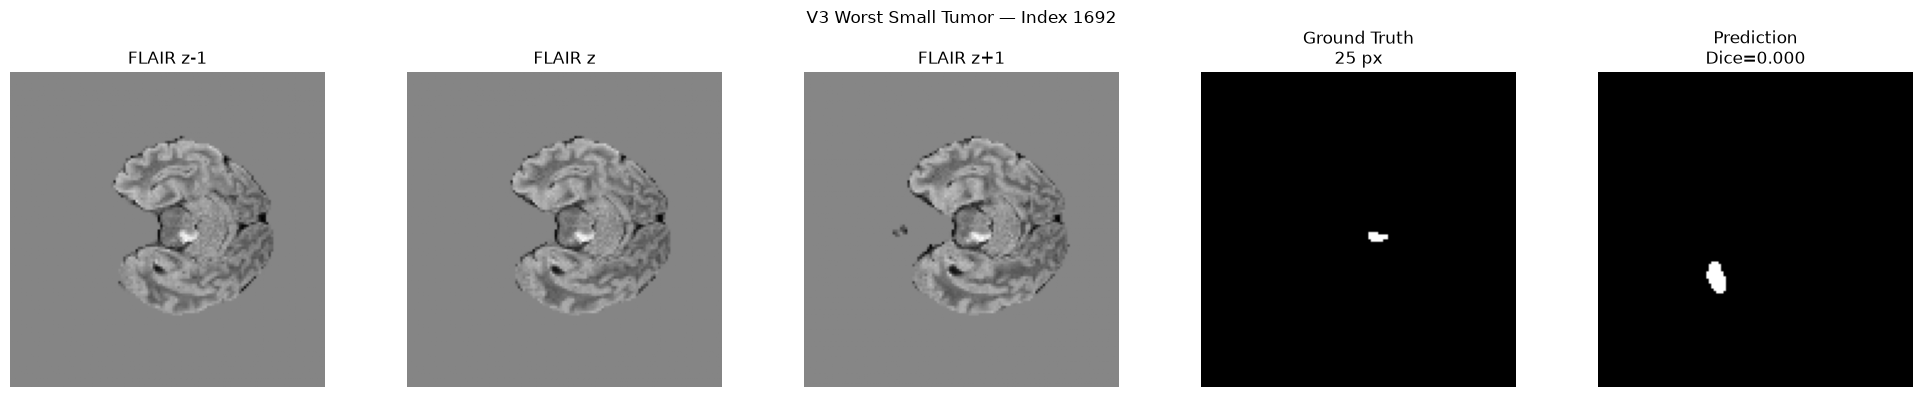

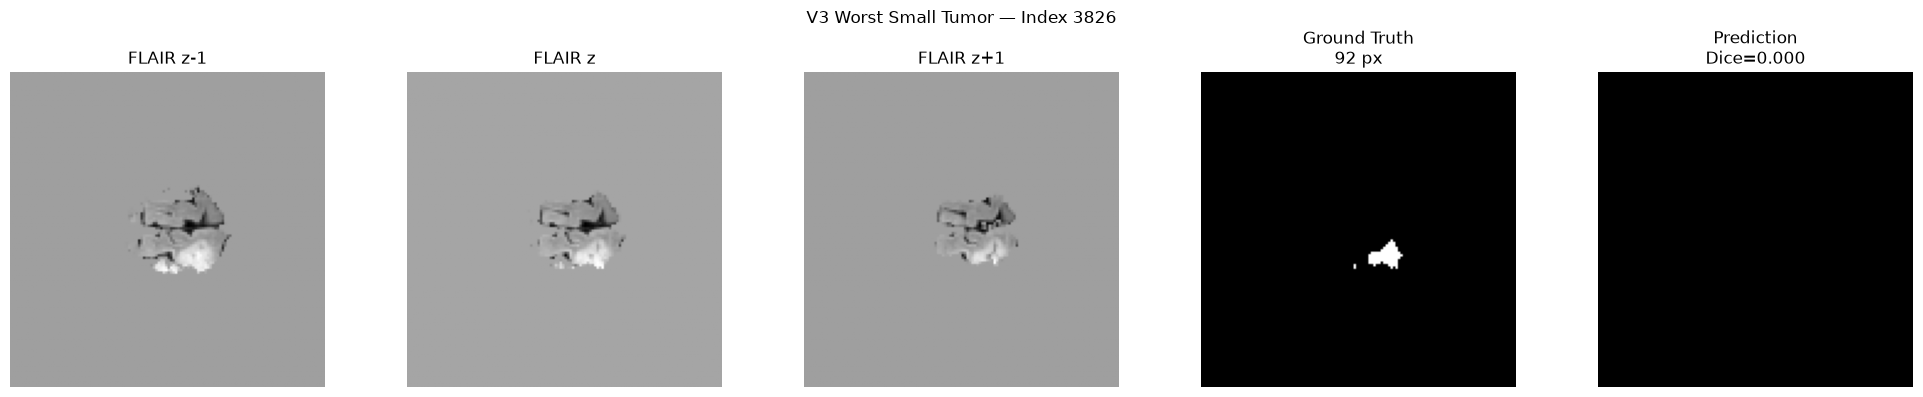

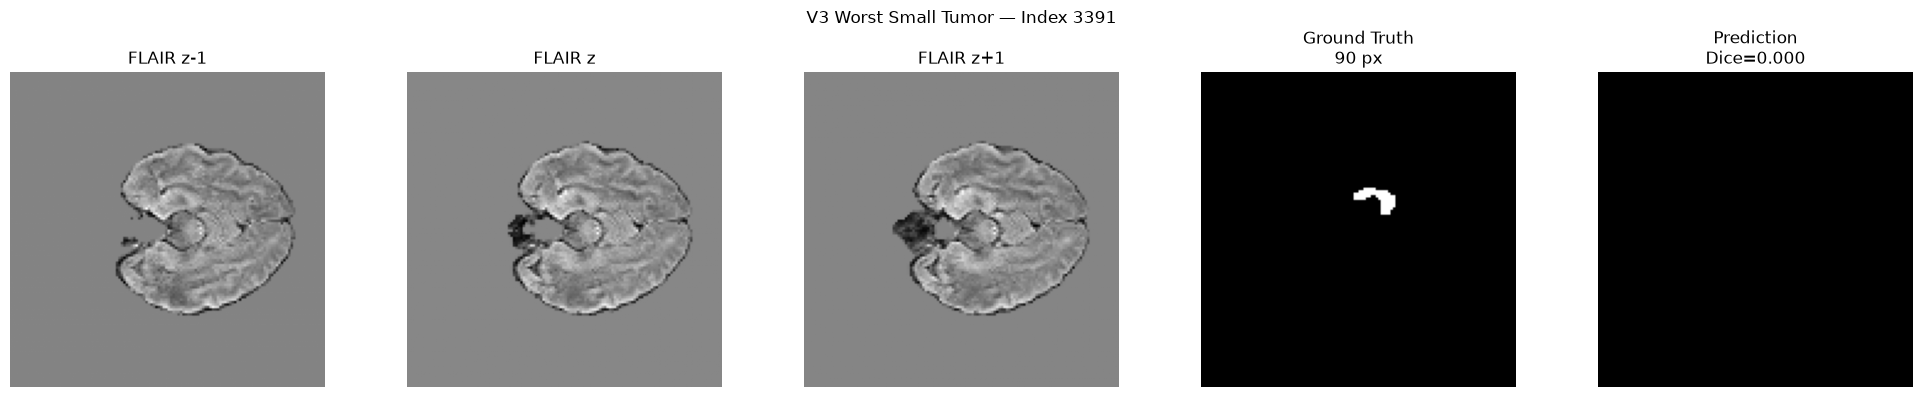

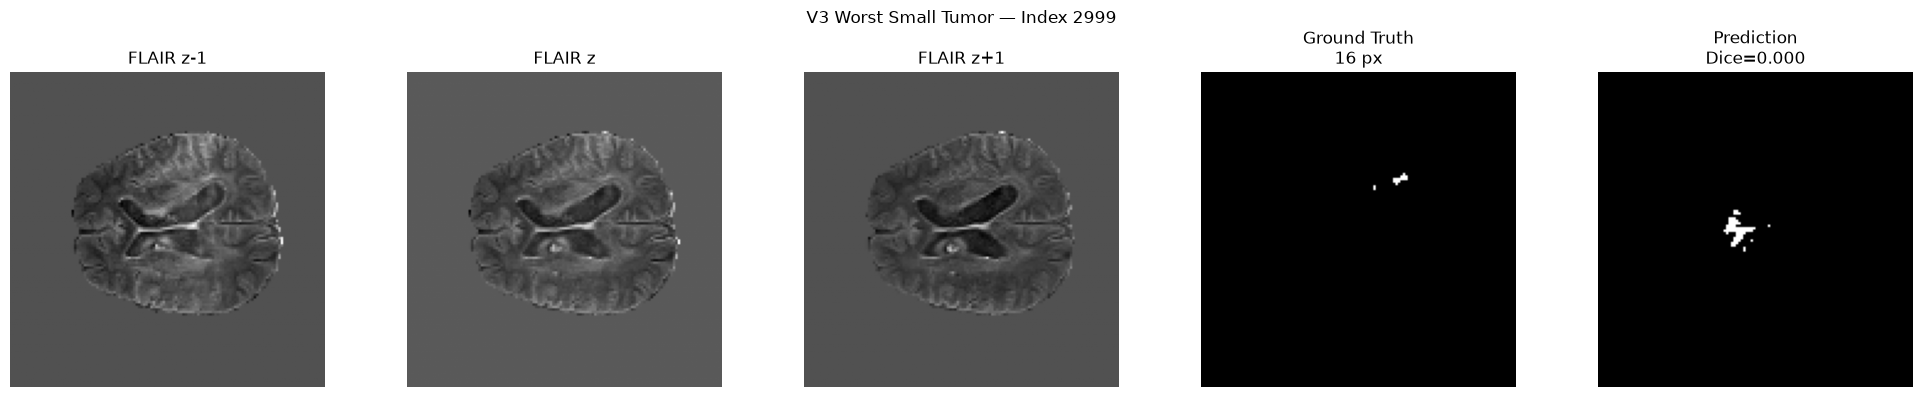

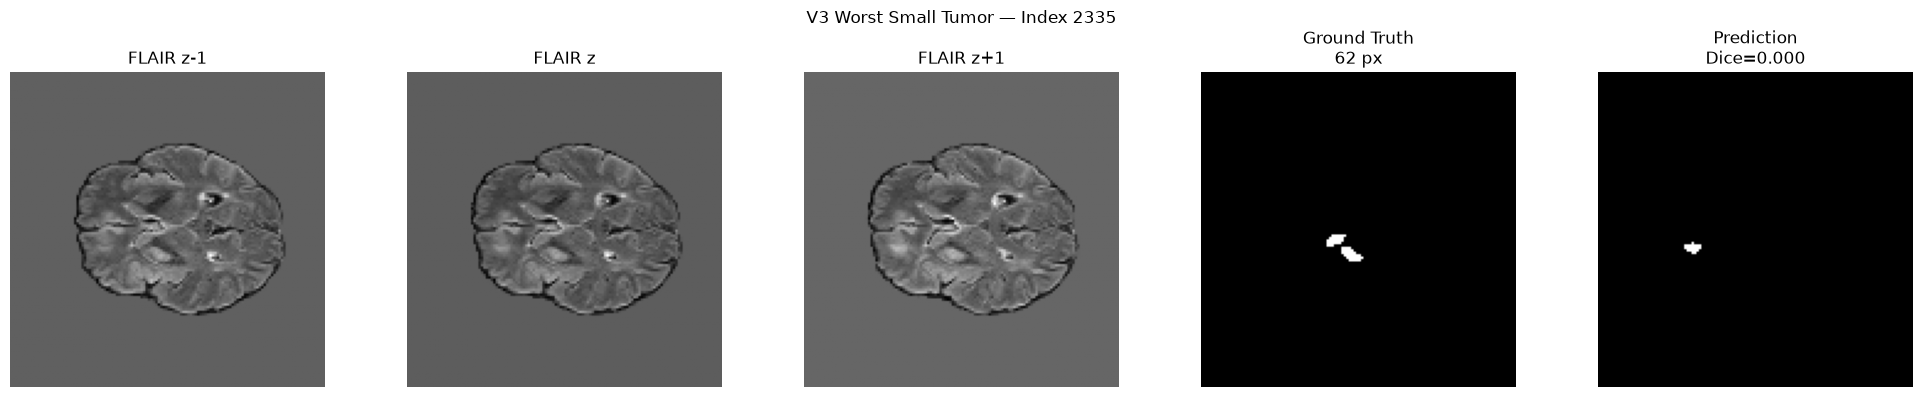

In [18]:
# ==================================================
# Visualize all 5 worst cases
# ==================================================

for case in worst_cases:

    idx = case["index"]

    image, mask = val_dataset[idx]

    image_np = image.numpy()
    mask_np = mask.numpy()

    input_tensor = (
        image.unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        logits = model(
            input_tensor
        )

        prediction = (
            torch.sigmoid(logits)[0, 0]
            > 0.5
        ).float().cpu().numpy()

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 4)
    )

    axes[0].imshow(
        image_np[3],
        cmap="gray"
    )
    axes[0].set_title("FLAIR z-1")

    axes[1].imshow(
        image_np[7],
        cmap="gray"
    )
    axes[1].set_title("FLAIR z")

    axes[2].imshow(
        image_np[11],
        cmap="gray"
    )
    axes[2].set_title("FLAIR z+1")

    axes[3].imshow(
        mask_np,
        cmap="gray"
    )
    axes[3].set_title(
        f"Ground Truth\n{case['gt_pixels']:.0f} px"
    )

    axes[4].imshow(
        prediction,
        cmap="gray"
    )
    axes[4].set_title(
        f"Prediction\nDice={case['dice']:.3f}"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"V3 Worst Small Tumor — Index {idx}"
    )

    plt.tight_layout()
    plt.show()

This visualization is very useful. It confirms that V3's remaining weakness is not primarily spatial context — it's small-lesion detection and class imbalance.

The important observation is that z−1, z, and z+1 contain useful anatomical context, but the target lesion itself is extremely small. The model often sees the surrounding anatomy but doesn't assign enough probability to the tiny tumor pixels.